# Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns

from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm

from statsmodels.tsa.holtwinters import ExponentialSmoothing



# Funções

In [2]:
def apresentar_estacionariedade(serie, log=True):
    resultado_adf = adfuller(serie)
    resultado_kpss = kpss(serie)
    estacionario = (resultado_adf[1] <= 0.05) and (resultado_kpss[1] > 0.05)
    if (log):
        print("="*40)
        print("Estatística ADF:", resultado_adf[0])
        print("p-valor ADF:", resultado_adf[1])
        print("p-valor KPSS:", resultado_kpss[1])
        print("É estacionário?", "Sim" if estacionario else "Não") # Se for menor igual a 0.05 significa que é estacionário
        print("Valores críticos:")
        for chave, valor in resultado_adf[4].items():
            print(f"    {chave}: {valor}")
    return estacionario
    

In [3]:
def tornar_estacionario(serie):
    diferenciacao = 0
    while not apresentar_estacionariedade(serie, False):
        diferenciacao += 1
        serie = serie.diff().dropna()
    
    return serie, diferenciacao

In [4]:
def analisar_series_temporais(df, coluna_data, figsize=(14, 5)):
    """
    Plota todas as colunas numéricas ao longo do tempo
    e gera uma matriz de correlação.

    Parameters
    ----------
    df : pandas.DataFrame
    coluna_data : str
        Nome da coluna de data.
    """

    if coluna_data not in df.columns:
        raise ValueError(f"Coluna '{coluna_data}' não encontrada.")

    # Cópia para evitar alterar o dataframe original
    df_plot = df.copy()

    # Conversão para datetime
    df_plot[coluna_data] = pd.to_datetime(df_plot[coluna_data])

    # Ordenação temporal
    df_plot = df_plot.sort_values(coluna_data)

    # Seleciona colunas numéricas
    colunas_numericas = df_plot.select_dtypes(include=np.number).columns

    # Plota cada série temporal
    for coluna in colunas_numericas:
        plt.figure(figsize=figsize)

        plt.plot(
            df_plot[coluna_data],
            df_plot[coluna]
        )

        plt.title(f"{coluna} ao longo do tempo")
        plt.xlabel(coluna_data)
        plt.ylabel(coluna)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Correlação
    correlacao = df_plot[colunas_numericas].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlacao,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Matriz de Correlação")
    plt.tight_layout()
    plt.show()

    return correlacao

In [5]:
def calcular_vif(df, colunas=None):
    """
    Calcula o Variance Inflation Factor (VIF) para as colunas informadas.

    Parameters
    ----------
    df : pandas.DataFrame
    colunas : list[str], optional
        Colunas a serem consideradas. Se None, utiliza todas as numéricas.

    Returns
    -------
    pandas.DataFrame
        DataFrame contendo Feature e VIF.
    """

    if colunas is None:
        colunas = df.select_dtypes(include=np.number).columns.tolist()

    X = df[colunas].copy()

    # Remove linhas com NaN
    X = X.dropna()

    vif_df = pd.DataFrame({
        "Feature": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

# Pegando dados

In [6]:
df_raw = pd.read_excel("data/serie_holtwinters.xlsx")
TARGET = "receita"   
df_raw.head(2)

,mes,receita
0,2016-01-01,870.253494
1,2016-02-01,836.848347


## Escalonando a base

In [7]:
scaler = StandardScaler().set_output(transform="pandas")

df_escalonado = df_raw.copy()

# Correlação

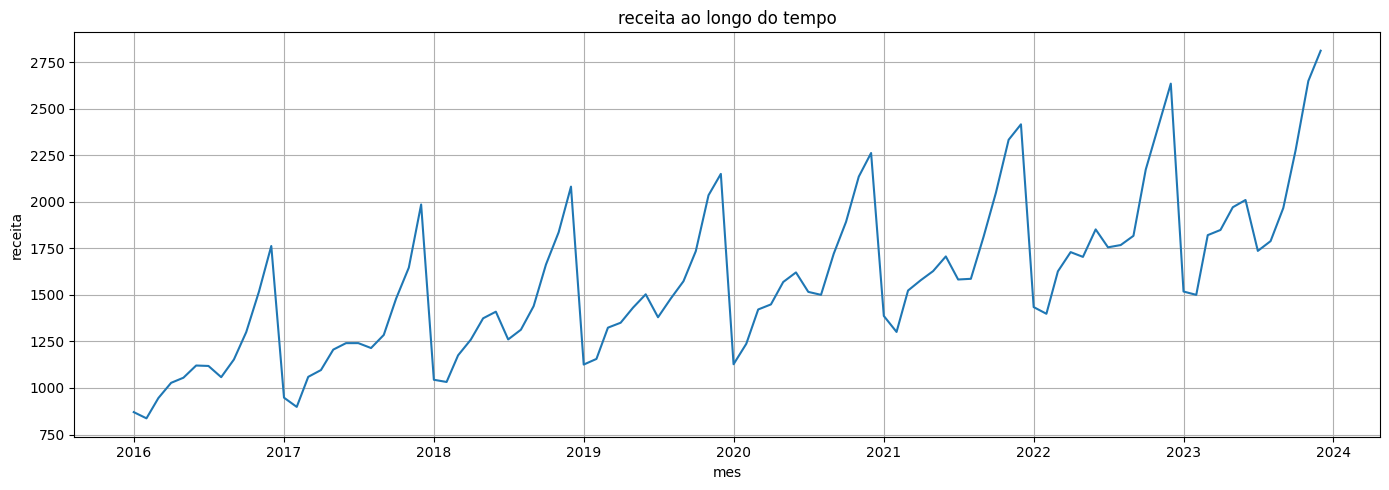

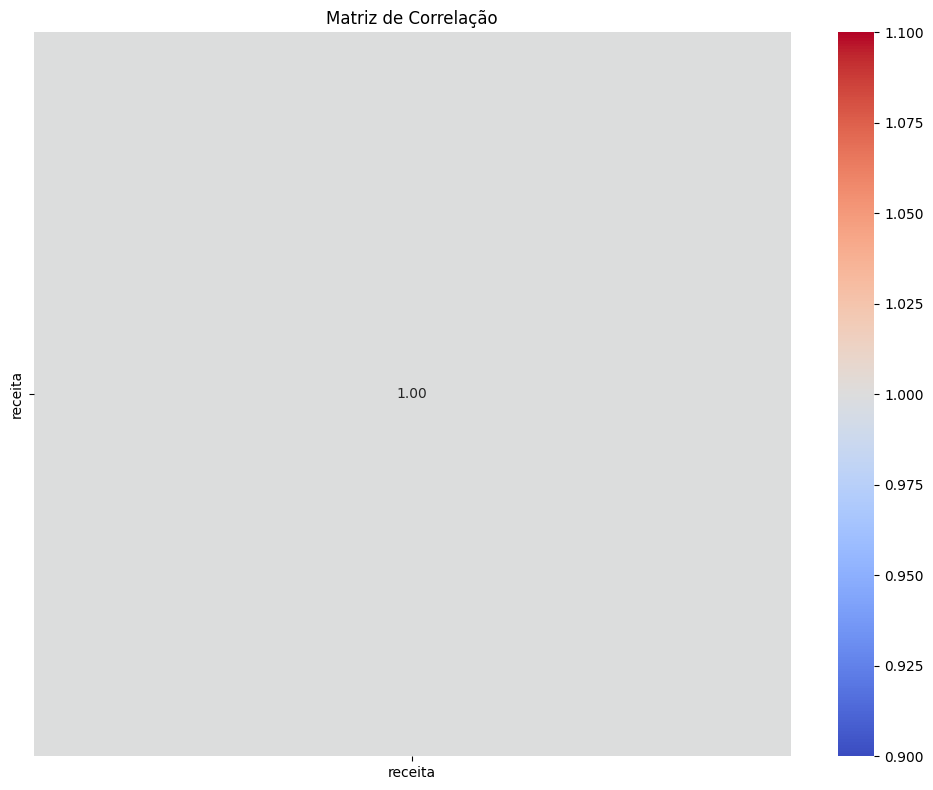

,receita
receita,1.0


In [8]:
analisar_series_temporais(df_escalonado, "mes")

# Separar treino e teste e escalonando

In [9]:
# pensando em 3 dias para prever
h = 12
train = df_escalonado[TARGET].iloc[:-h]
# train[["temperatura"]] = scaler.fit_transform(train[["temperatura"]])

test  = df_escalonado[TARGET].iloc[-h:]
# test[["temperatura"]] = scaler.transform(test[["temperatura"]])


# PACF e ACF

<Figure size 1000x400 with 0 Axes>

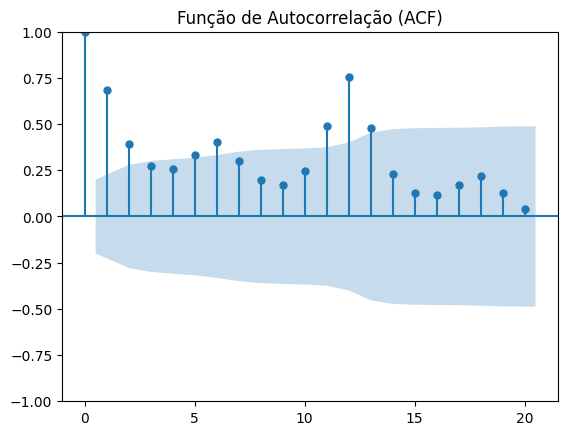

<Figure size 1000x400 with 0 Axes>

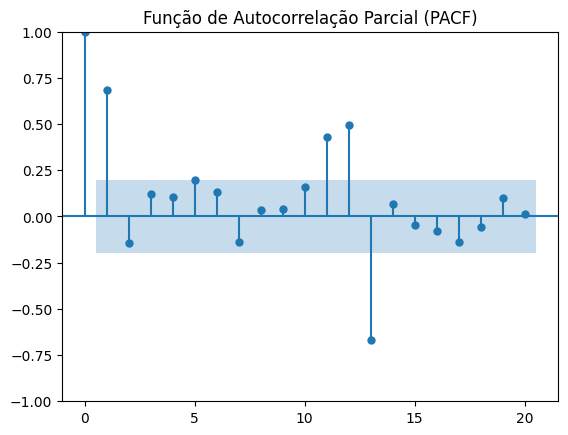

In [10]:
MAX_LAG = 20
plt.figure(figsize=[10,4])
plot_acf(df_escalonado[TARGET], lags=MAX_LAG, title="Função de Autocorrelação (ACF)")
plt.show()

plt.figure(figsize=[10,4])
plot_pacf(df_escalonado[TARGET], lags=MAX_LAG, title="Função de Autocorrelação Parcial (PACF)")
plt.show()

# STL (Força de sazonalidade)

Fazer um range de 0 a 50, calcular a força para cada um, ordenar as forças de menor para maior, pegar o ultimo quartil e pegar o menor m dentro do ultimo quartil

In [11]:
range_m = range(2,30)
forcas_sazonalidades = []

for m in range_m:
    stl = STL(df_escalonado[TARGET], period=m, robust=True).fit()
    forca_sazonalidade = 1 - (np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
    forcas_sazonalidades.append({"m":m, "forca":forca_sazonalidade}) 

forcas_sazonalidades = sorted(forcas_sazonalidades, key=lambda x: x["forca"],reverse=True)
print("Melhores M:")
i = 1
for forca in forcas_sazonalidades:
    num_forma_formatado = forca['forca']
    num_forma_formatado = round(num_forma_formatado*100, 3)
    print(f"{i}° - M: {forca['m']} - Força: {num_forma_formatado}")
    i+=1


Melhores M:
1° - M: 12 - Força: 98.842
2° - M: 24 - Força: 98.232
3° - M: 18 - Força: 43.045
4° - M: 25 - Força: 39.598
5° - M: 6 - Força: 34.571
6° - M: 29 - Força: 32.121
7° - M: 27 - Força: 29.435
8° - M: 23 - Força: 25.778
9° - M: 26 - Força: 25.713
10° - M: 19 - Força: 21.759
11° - M: 13 - Força: 21.147
12° - M: 2 - Força: 17.292
13° - M: 17 - Força: 16.077
14° - M: 16 - Força: 15.112
15° - M: 7 - Força: 13.274
16° - M: 20 - Força: 13.015
17° - M: 11 - Força: 11.227
18° - M: 15 - Força: 11.079
19° - M: 28 - Força: 6.077
20° - M: 5 - Força: 5.747
21° - M: 3 - Força: 4.021
22° - M: 9 - Força: 0.714
23° - M: 4 - Força: -3.216
24° - M: 14 - Força: -8.575
25° - M: 10 - Força: -12.517
26° - M: 22 - Força: -16.936
27° - M: 21 - Força: -16.981
28° - M: 8 - Força: -18.185


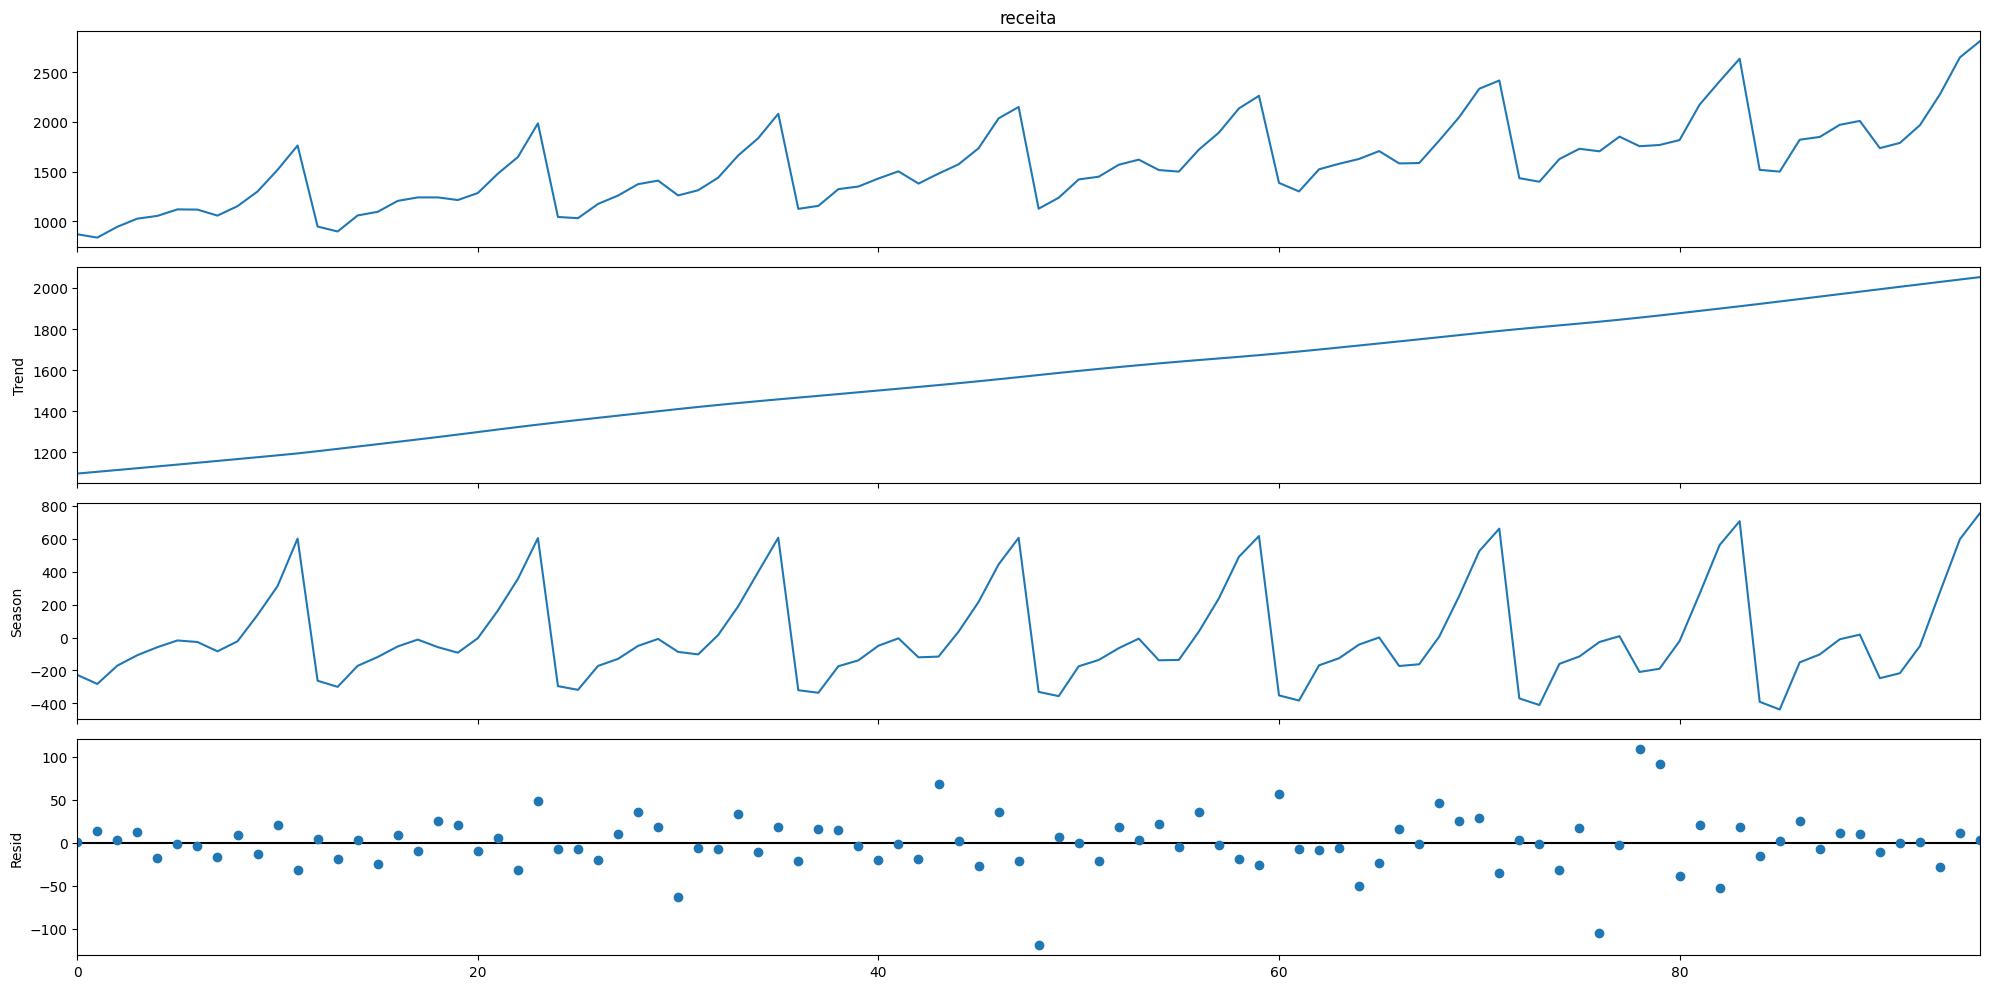

In [12]:
m = 12
stl = STL(df_escalonado[TARGET], period=m, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(20,10)
plt.tight_layout()
plt.show()

In [13]:
forca_sazonalidade = 1 - (np.var(stl.resid) / np.var(stl.seasonal + stl.resid))

print(f"Força de sazonalidade (0-1): {forca_sazonalidade:.4f}")

Força de sazonalidade (0-1): 0.9884


# Modelos

## Aditivo

In [14]:
hw_add = ExponentialSmoothing(
train, trend='add', seasonal='add', seasonal_periods=12, initialization_method='heuristic'
).fit()

print(f"AIC (Holt-Winters aditivo): {hw_add.aic:.2f}")
print(f"BIC (Holt-Winters aditivo): {hw_add.bic:.2f}")

AIC (Holt-Winters aditivo): 693.77
BIC (Holt-Winters aditivo): 732.67


## Multiplicativo

In [15]:
hw_mul = ExponentialSmoothing(
train, trend='add', seasonal='mul', seasonal_periods=12, initialization_method='heuristic'
).fit()

print(f"AIC (Holt-Winters multiplicativo): {hw_mul.aic:.2f}  |  aditivo: {hw_add.aic:.2f}")
print(f"BIC (Holt-Winters multiplicativo): {hw_mul.bic:.2f}  |  aditivo: {hw_add.bic:.2f}")

AIC (Holt-Winters multiplicativo): 681.78  |  aditivo: 693.77
BIC (Holt-Winters multiplicativo): 720.67  |  aditivo: 732.67


MAE Holt-Winters aditivo: 71.21
MAE Holt-Winters mult.: 55.12


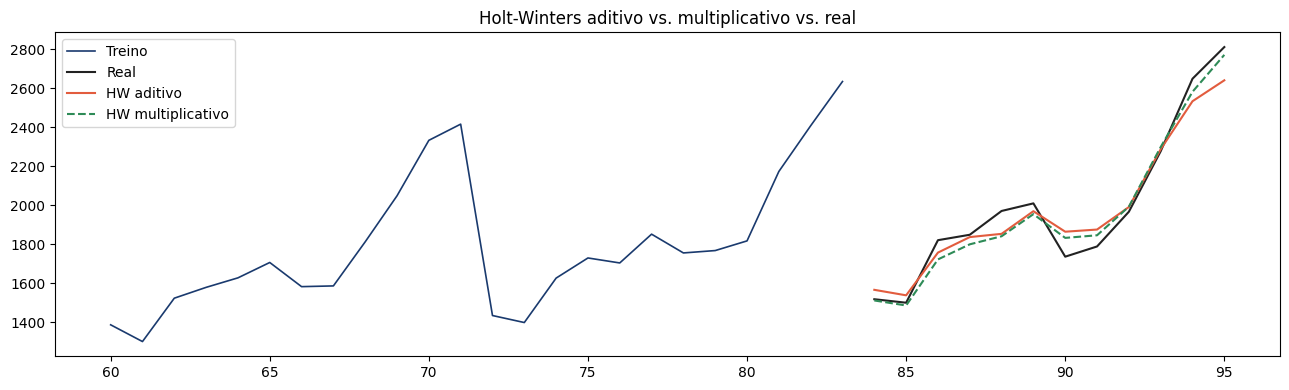

In [16]:
fc_add = hw_add.forecast(h)
fc_mul = hw_mul.forecast(h)

mae_add = mean_absolute_error(test, fc_add) 
mae_mul = mean_absolute_error(test, fc_mul) 

print(f"MAE Holt-Winters aditivo: {mae_add:.2f}")
print(f"MAE Holt-Winters mult.: {mae_mul:.2f}")

fig, ax = plt.subplots (figsize=(13, 4))
ax.plot(train[-24:].index, train [-24:], label='Treino', color='#1a3a6e', linewidth=1.2)
ax.plot(test.index, test, label='Real', color='#222', linewidth=1.5)
ax.plot(fc_add.index, fc_add, '', label='HW aditivo', color='#e25c3e', linewidth=1.5)
ax.plot(fc_mul.index, fc_mul, '--', label='HW multiplicativo', color='#2e8b57', linewidth=1.5)
ax.set_title('Holt-Winters aditivo vs. multiplicativo vs. real')
ax.legend()
plt.tight_layout()
plt.show()

## Análise dos parâmetros

Parâmetros estimados (Holt-Winters multiplicativo):
  smoothing_level      = 0.0767
  smoothing_trend      = 0.0076
  smoothing_seasonal   = 0.4320


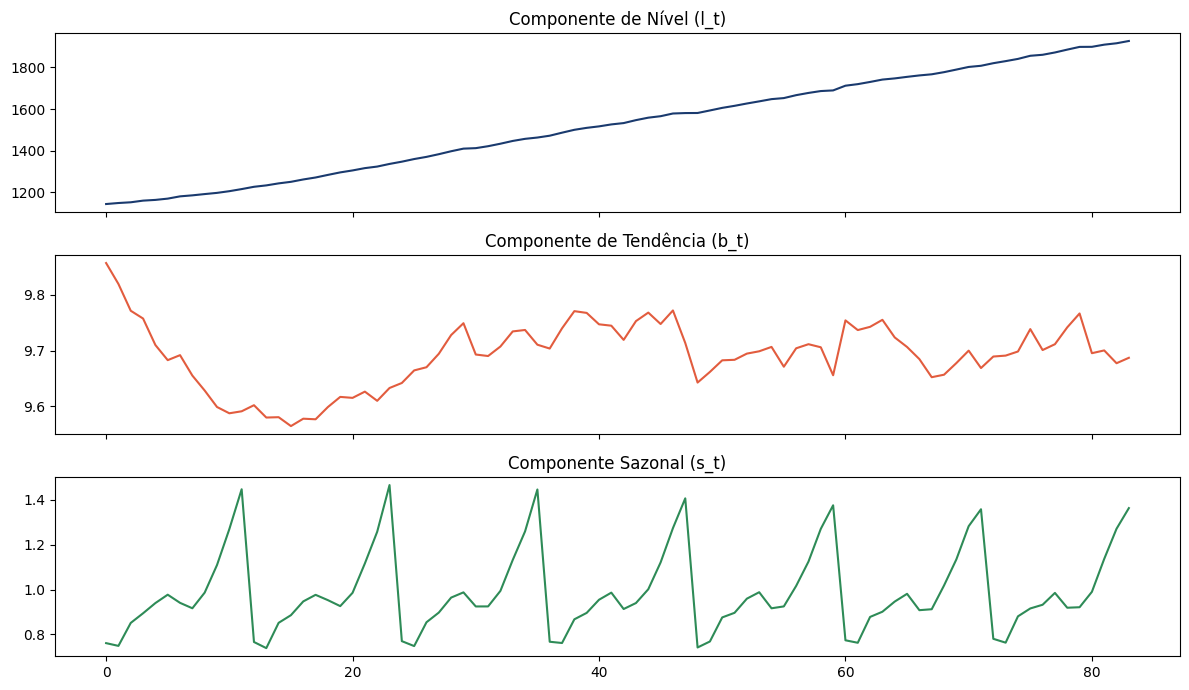

In [17]:
params = hw_mul.params
print("Parâmetros estimados (Holt-Winters multiplicativo):")
for nome in ["smoothing_level", "smoothing_trend", "smoothing_seasonal"]:
    print(f"  {nome:<20} = {params[nome]:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(train.index, hw_mul.level, color='#1a3a6e')
axes[0].set_title('Componente de Nível (l_t)')
axes[1].plot(train.index, hw_mul.trend, color='#e25c3e')
axes[1].set_title('Componente de Tendência (b_t)')
axes[2].plot(train.index, hw_mul.season, color='#2e8b57')
axes[2].set_title('Componente Sazonal (s_t)')
plt.tight_layout()
plt.show()

## Resíduo

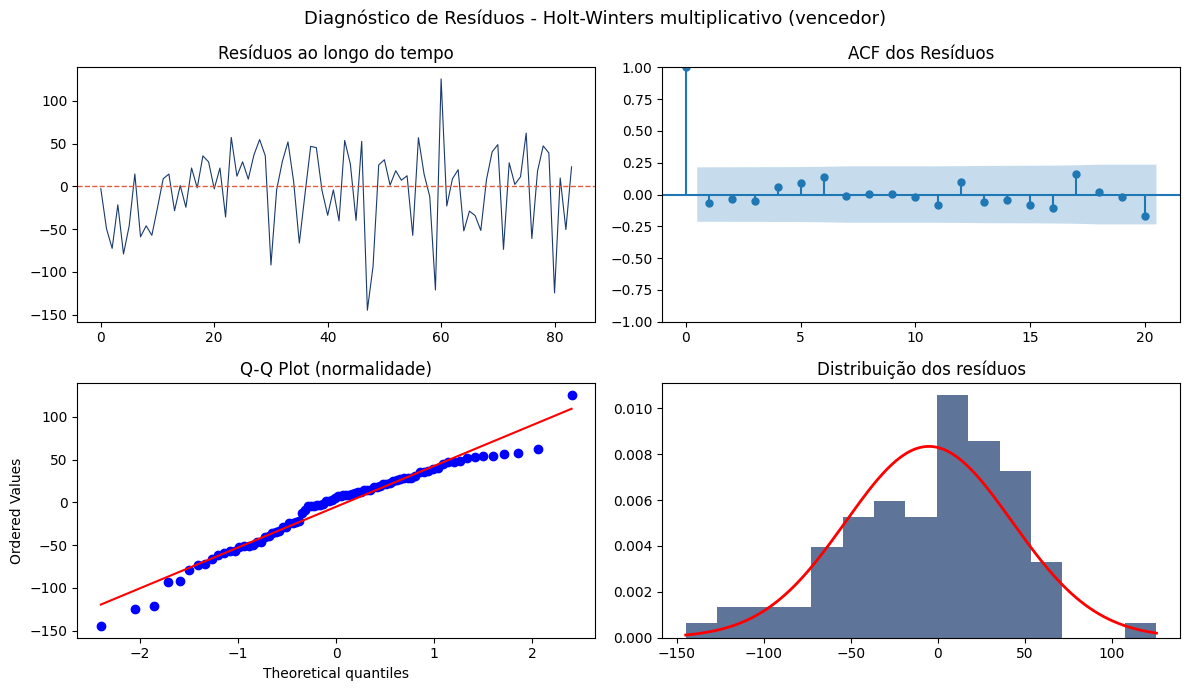

Ljung-Box (H0: resíduos sem autocorrelação):
    lb_stat  lb_pvalue
1    0.3417     0.5588
2    0.4629     0.7934
3    0.7233     0.8677
4    1.0146     0.9076
5    1.8109     0.8746
6    3.4899     0.7453
7    3.4991     0.8353
8    3.5019     0.8990
9    3.5077     0.9407
10   3.5444     0.9656
11   4.1579     0.9651
12   5.1142     0.9541


In [18]:
resid = hw_mul.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(resid.index, resid, color="#1a3a6e", linewidth=0.8)
axes[0, 0].axhline(0, color="#e25c3e", linewidth=1, linestyle="--")
axes[0, 0].set_title("Resíduos ao longo do tempo")

plot_acf(resid, lags=20, ax=axes[0, 1], title="ACF dos Resíduos")

stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot (normalidade)")

axes[1, 1].hist(resid, bins=15, density=True, color="#1a3a6e", alpha=0.7)
x = np.linspace(resid.min(), resid.max(), 200)
axes[1, 1].plot(x, norm.pdf(x, resid.mean(), resid.std()), "r-", linewidth=2)
axes[1, 1].set_title("Distribuição dos resíduos")

plt.suptitle("Diagnóstico de Resíduos - Holt-Winters multiplicativo (vencedor)", fontsize=13)
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=12, return_df=True)
print("Ljung-Box (H0: resíduos sem autocorrelação):")
print(lb[["lb_stat", "lb_pvalue"]].round(4))
todos_ok = (lb["lb_pvalue"] > 0.05).all()

# Atividades

## 1. Comparação com SARIMA

In [19]:
# espaco de busca
m = 12
p_range = [0,1,2]
d_range = [0,1]
q_range = [0,1,2]
P_range = [0,1,2]
D_range = [0,1]
Q_range = [0,1,2]

def tentar_sarima(order, seasonal_order, y):
    try:
        model = SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False, maxiter=100)
        return res

    except Exception:
        return None


In [20]:
import os
import json

In [21]:
models = []
arquivo = "modelos.json"

for p in p_range:
    for d in d_range:
        for q in q_range:
            for P in P_range:
                for D in D_range:
                    for Q in Q_range:
                        print(f"\nModelo: {p},{d},{q} | {P},{D},{Q}")

                        # Se o arquivo não existir, cria uma lista vazia
                        if os.path.exists(arquivo):
                            with open(arquivo, "r", encoding="utf-8") as f:
                                dados = json.load(f)
                        else:
                            dados = []

                        ja_existe = any(
                            item.get("parameters") == [[p,d,q],[P,D,Q,m]]
                            for item in dados
                        )

                        if ja_existe:
                            continue

                        modelo = tentar_sarima((p,d,q),(P,D,Q,m), train)
                        if modelo:
                            print("Bic:", modelo.bic)
                            json_modelo = {"parameters":((p,d,q),(P,D,Q,m)), "bic":modelo.bic}
                        
                            # Adiciona o novo dicionário
                            dados.append(json_modelo)

                            # Salva novamente
                            with open(arquivo, "w", encoding="utf-8") as f:
                                json.dump(dados, f, ensure_ascii=False, indent=4)


Modelo: 0,0,0 | 0,0,0

Modelo: 0,0,0 | 0,0,1

Modelo: 0,0,0 | 0,0,2

Modelo: 0,0,0 | 0,1,0

Modelo: 0,0,0 | 0,1,1

Modelo: 0,0,0 | 0,1,2

Modelo: 0,0,0 | 1,0,0

Modelo: 0,0,0 | 1,0,1

Modelo: 0,0,0 | 1,0,2

Modelo: 0,0,0 | 1,1,0

Modelo: 0,0,0 | 1,1,1

Modelo: 0,0,0 | 1,1,2

Modelo: 0,0,0 | 2,0,0

Modelo: 0,0,0 | 2,0,1

Modelo: 0,0,0 | 2,0,2

Modelo: 0,0,0 | 2,1,0

Modelo: 0,0,0 | 2,1,1

Modelo: 0,0,0 | 2,1,2

Modelo: 0,0,1 | 0,0,0

Modelo: 0,0,1 | 0,0,1

Modelo: 0,0,1 | 0,0,2

Modelo: 0,0,1 | 0,1,0

Modelo: 0,0,1 | 0,1,1

Modelo: 0,0,1 | 0,1,2

Modelo: 0,0,1 | 1,0,0

Modelo: 0,0,1 | 1,0,1

Modelo: 0,0,1 | 1,0,2

Modelo: 0,0,1 | 1,1,0

Modelo: 0,0,1 | 1,1,1

Modelo: 0,0,1 | 1,1,2

Modelo: 0,0,1 | 2,0,0

Modelo: 0,0,1 | 2,0,1

Modelo: 0,0,1 | 2,0,2

Modelo: 0,0,1 | 2,1,0

Modelo: 0,0,1 | 2,1,1

Modelo: 0,0,1 | 2,1,2

Modelo: 0,0,2 | 0,0,0

Modelo: 0,0,2 | 0,0,1

Modelo: 0,0,2 | 0,0,2

Modelo: 0,0,2 | 0,1,0

Modelo: 0,0,2 | 0,1,1

Modelo: 0,0,2 | 0,1,2

Modelo: 0,0,2 | 1,0,0

Modelo: 0,

In [22]:
if os.path.exists(arquivo):
    with open(arquivo, "r", encoding="utf-8") as f:
        models = json.load(f)

melhor_resultado = sorted(models, key=lambda x: x["bic"])[0]
melhores_parametros = melhor_resultado["parameters"]

print("Melhores parametros:", melhores_parametros)

print("\nMelhor SARIMA BIC:", melhor_resultado["bic"])
print("Holt Winters BIC:", hw_mul.bic)

melhor_modelo = tentar_sarima(melhores_parametros[0], melhores_parametros[1], train)

fc_melhor = melhor_modelo.forecast(steps=h)
mae_melhor = mean_absolute_error(test, fc_melhor)

print(f"\nMAE do melhor SARIMA: {mae_melhor:.2f}")
print("MAE do Holt Winters:", mae_mul)

Melhores parametros: [[2, 0, 1], [0, 0, 2, 12]]

Melhor SARIMA BIC: 24.362658063278516
Holt Winters BIC: 720.6742601833616

MAE do melhor SARIMA: 85407703474129211393127706745378170456319993580406373875029859878663976228265092218055819264.00
MAE do Holt Winters: 55.119599179583815


## 2. Desafio

In [23]:
# "What if" analysis: Feriado vs. Sem Feriado
# Previsão para as próximas 4 semanas com temperatura constante de 22°C

# Temperatura constante em 22°C (antes de escalar)
temp_constante = 22.0

# Escalar a temperatura usando o scaler já ajustado
temp_scaled = scaler.transform([[temp_constante]]).iloc[0]["temperatura"]

# Cenário A: Sem feriado (feriado = 0)
exog_cenario_a = pd.DataFrame({
    'temperatura': [temp_scaled] * 4,
    'feriado': [0] * 4
})

# Cenário B: Com feriado (feriado = 1)
exog_cenario_b = pd.DataFrame({
    'temperatura': [temp_scaled] * 4,
    'feriado': [1] * 4
})

# Previsões
fc_cenario_a = modelo_exog.get_forecast(steps=4, exog=exog_cenario_a)
pred_cenario_a = fc_cenario_a.predicted_mean

fc_cenario_b = modelo_exog.get_forecast(steps=4, exog=exog_cenario_b)
pred_cenario_b = fc_cenario_b.predicted_mean

# Diferença média entre os cenários
diferenca_media = (pred_cenario_a - pred_cenario_b).mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 5), pred_cenario_a.values, 'o-', label='Sem Feriado (feriado=0)', linewidth=2, markersize=8)
ax.plot(range(1, 5), pred_cenario_b.values, 's-', label='Com Feriado (feriado=1)', linewidth=2, markersize=8)
ax.set_xlabel('Semanas')
ax.set_ylabel('Vendas Previstas')
ax.set_title('What If: Impacto do Feriado nas Próximas 4 Semanas\n(Temperatura constante = 22°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumo
print("="*60)
print("ANÁLISE 'WHAT IF': IMPACTO DO FERIADO")
print("="*60)
print(f"\nCenário A - Sem Feriado (feriado=0):")
print(pred_cenario_a.values)
print(f"\nCenário B - Com Feriado (feriado=1):")
print(pred_cenario_b.values)
print(f"\nDiferença (Sem Feriado - Com Feriado): {diferenca_media:.2f}")
print(f"Impacto percentual: {(diferenca_media / pred_cenario_a.mean()) * 100:.2f}%")
print("="*60)   

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.